# Analysing LiTS dataset

In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
from idssp.sonk.view import utils
from idssp.sonk.model.data import DataWrapper, VolumeWrapper
from idssp.sonk.model.training import ModelBuilder
from idssp.sonk.disk.loader import DataCollector
from monai.utils import set_determinism

from idssp.sonk import config

from IPython.display import HTML

Importing torch... (This may take a moment)
🚀 Loading configuration for environment: [LOCAL]
Running in LOCAL environment.
   Device: cpu
   Batch Size: 1
   Val Batch Size: 1
   Workers: 0
   Data Root: /media/sonk/77E0938A53FF065D/ct-scans/media/nas/01_Datasets/CT/LITS/Training Batch 1
   Checkpoint Dir: checkpoints


In [4]:
set_determinism(seed=config.RANDOM_SEED)

## Loading the files

In [5]:
loader = DataCollector()

loader.read_dir(config.CT_ROOT, ds_source='LiTS')
loader.extract_images_and_labels()

Reading directory: /media/sonk/77E0938A53FF065D/ct-scans/media/nas/01_Datasets/CT/LITS/Training Batch 1
Found 56 files in the directory.
Extracted 28 image-label pairs from the dataset.


In [6]:
# print the first 5 data sources to verify
loader.datasources[:5]

[{'image': '/media/sonk/77E0938A53FF065D/ct-scans/media/nas/01_Datasets/CT/LITS/Training Batch 1/volume-0.nii',
  'label': '/media/sonk/77E0938A53FF065D/ct-scans/media/nas/01_Datasets/CT/LITS/Training Batch 1/segmentation-0.nii'},
 {'image': '/media/sonk/77E0938A53FF065D/ct-scans/media/nas/01_Datasets/CT/LITS/Training Batch 1/volume-1.nii',
  'label': '/media/sonk/77E0938A53FF065D/ct-scans/media/nas/01_Datasets/CT/LITS/Training Batch 1/segmentation-1.nii'},
 {'image': '/media/sonk/77E0938A53FF065D/ct-scans/media/nas/01_Datasets/CT/LITS/Training Batch 1/volume-10.nii',
  'label': '/media/sonk/77E0938A53FF065D/ct-scans/media/nas/01_Datasets/CT/LITS/Training Batch 1/segmentation-10.nii'},
 {'image': '/media/sonk/77E0938A53FF065D/ct-scans/media/nas/01_Datasets/CT/LITS/Training Batch 1/volume-11.nii',
  'label': '/media/sonk/77E0938A53FF065D/ct-scans/media/nas/01_Datasets/CT/LITS/Training Batch 1/segmentation-11.nii'},
 {'image': '/media/sonk/77E0938A53FF065D/ct-scans/media/nas/01_Datasets/

## Analysing the data

In [7]:
wrapper = DataWrapper()
index = 1

wrapper.set_volume(loader.datasources[index]['image'], loader.datasources[index]['label'])

Loading data for volume...
Data loaded successfully.
Calculating unique values in the label data...
Finding slice information...
done!


In [8]:
wrapper.print_summary_of_volume()

Volume summary:
--------------------File paths--------------------
Image path: /media/sonk/77E0938A53FF065D/ct-scans/media/nas/01_Datasets/CT/LITS/Training Batch 1/volume-1.nii
Label path: /media/sonk/77E0938A53FF065D/ct-scans/media/nas/01_Datasets/CT/LITS/Training Batch 1/segmentation-1.nii
--------------------File shapes--------------------
Image shape: (512, 512, 123)
Label shape: (512, 512, 123)
--------------------Data arrays--------------------
Image data shape: (512, 512, 123)
Mask data shape: (512, 512, 123)
--------------------- value ranges--------------------
CT intensity range: -3024.0 to 3071.0
Mask intensity range: 0 to 2
Voxel dimensions (mm): (np.float32(0.675781), np.float32(0.675781), np.float32(5.0))
--------------------Affine information--------------------
Image affine transformation matrix:
 [[  -0.67578101    0.            0.          177.19999695]
 [   0.            0.67578101    0.         -172.32409668]
 [   0.            0.            5.         -560.25      

## Visualising the data

Plotting slice 58 of volume...


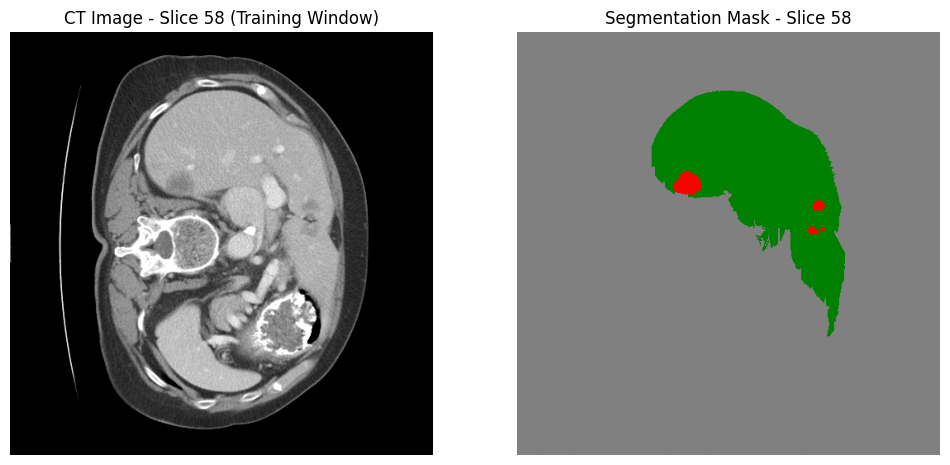

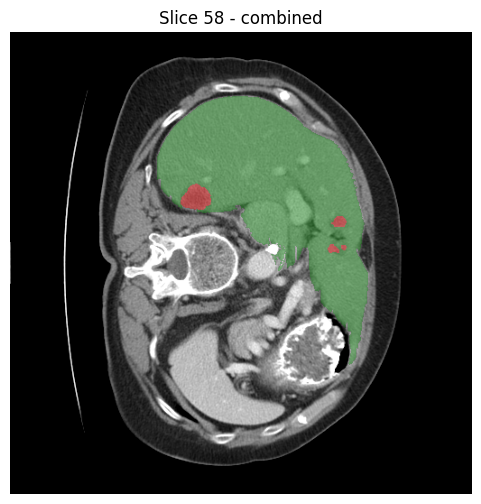

In [9]:
wrapper.plot_slice(58)

The following cell takes too much space, so just run it
locally

In [13]:
#HTML(wrapper.get_animation_motion().to_jshtml())

In [11]:
utils.slice_to_world_coordinates(wrapper.volume.image, wrapper.volume.slice_thresholds['liver']['first'])

np.float64(-335.25)

## Model training

In [4]:
import torch
import torch.optim as optim
from monai.networks.nets import UNet
from monai.losses import DiceLoss

### Data loading

In [49]:
train_files, val_files = loader.get_reproducible_split()

Split dataset into 22 training and 6 validation samples.
Split logged to LiTS_split_seed42.json


In [42]:
builder = ModelBuilder()

builder.init_data_loaders(train_files, val_files)

ModelBuilder initialized. Device set to: cpu
Creating training transforms object...
Creating validation transforms object...
Validation transforms: Using random crop for limited environment.
Initializing training and validation datasets...
Limited environment detected. Using regular Dataset.
Creating training dataloader...
Creating validation dataloader...
Data loaders initialized successfully.


### Modelling

It's gonna be a basic UNet

In [43]:
builder.init_model()

Initializing model...
Model initialized on cpu
Optimizer: AdamW | LR: 0.0001 | Weight Decay: 1e-5
Scheduler initialized: ReduceLROnPlateau (patience=5, factor=0.5)


### Training

In [ ]:
# start small, increase later
builder.train(10)

Epoch 1/10
